# RadHarmony — Evaluating a Foundation Model

A follow-on to the [hands-on introduction](radharmony_hands_on.ipynb): that one
**loads** datasets, this one **evaluates** foundation models on them.

We use **MedGemma** three ways:

1. Its **image encoder** for a linear probe — TB classification on Montgomery.
2. The full model for **visual question answering** — VQA-RAD.
3. The full model for **chest-X-ray report generation** — MIMIC-CXR.

The VQA and report-gen sections follow the MedGemma paper's protocol (same
model, prompts, decoding, metrics), so results are comparable to the paper.

## Setup

All three sections use MedGemma-family models on a recent `transformers`, so one
environment covers everything:

```bash
uv pip install -e ".[medsiglip,medgemma_gen]"
```

Requirements:

- **A GPU** (weights download on first use).
- **Hugging Face auth** — `google/medsiglip-448` and `google/medgemma-4b-it` are
  gated. Accept their licenses, then run `.venv/bin/hf auth login` once.

The RadGraph metric in the last section may need its own `radeval` environment
(see that section's note).

In [1]:
import os

# Pick the GPU. Must run BEFORE torch/CUDA is imported below, so `device_map="auto"`
# in the two VLM sections sees only this device instead of every GPU on the machine.
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
DEVICE = "cuda"  # after the mask, the chosen GPU is cuda:0

from radharmony.dataset import MontgomeryCXRDataset

MONTGOMERY_DIR = "/mnt/NAS4/datasets/external/Montgomery-CXR/MontgomerySet/CXR_png"

## Foundation models and linear probes

A **foundation model** is pre-trained on lots of data; its learned
representations transfer to new tasks without retraining.

The cheapest way to test one is a **linear probe**: freeze the model, turn each
image into an embedding, then fit a small classifier on top.

MedGemma is a vision-language model, so its native output is text. But its image
encoder — [MedSigLIP](https://huggingface.co/google/medsiglip-448), shipped
separately by Google — does produce embeddings. Below we probe MedSigLIP on
tuberculosis classification (Montgomery set).

In [2]:
from radharmony.evaluator.backbones import make_medsiglip
from radharmony.evaluator import LinearProbeEvaluator

# MedSigLIP is MedGemma-4B's image encoder (google/medsiglip-448, gated on HF).
# The recipe returns (transform, image encoder, text encoder, processor); a
# linear probe needs only the first two.
transform, encoder, _text_encoder, _processor = make_medsiglip(
    device=DEVICE, output_keys={"img", "cls"}
)

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Each encoder expects its own normalization, so we pass the recipe's `transform`
to the dataset instead of RadHarmony's default. Otherwise the call is identical
to the hands-on notebook.

In [3]:
probe_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    transform=transform,  # MedSigLIP's preprocessing
    output_cls=True,
    cache_dir=None,
)

`LinearProbeEvaluator` does the rest: embed every image, run 5-fold
cross-validation, and score each fold on its held-out images.

In [4]:
probe = LinearProbeEvaluator(
    image_encoder=encoder,
    dataset=probe_ds,
    n_folds=5,
    batch_size=32,
    device=DEVICE,
    embedding_cache="./cache/montgomery_medsiglip_emb",  # embeddings reused on re-runs
)
results = probe.evaluate()

# Average metrics across the folds, per label.
results.groupby("label")[["auroc", "auprc", "f1"]].mean()

,auroc,auprc,f1
label,,,
macro_average,0.972443,0.975077,0.947694
tb,0.972443,0.975077,0.947694


A per-label metrics table (AUROC, AUPRC, F1, and others). Every RadHarmony
evaluator returns this same shape, so scores across models are directly
comparable.

- **AUROC** — how well the model separates positive from negative cases
  (1.0 perfect, 0.5 chance).

k-NN, SVM, prototype, zero-shot, fine-tune, and segmentation use the same
interface — see [`evaluator_tutorial.ipynb`](evaluator_tutorial.ipynb).

### Seeing the predictions

The table aggregates AUROC across folds; the same probe also assigns a
probability to each image. We reuse the embeddings cached above, train the
TB head on one fold's training patients, then read off `P(TB)` for a few
held-out validation images — pairing each with its true label.

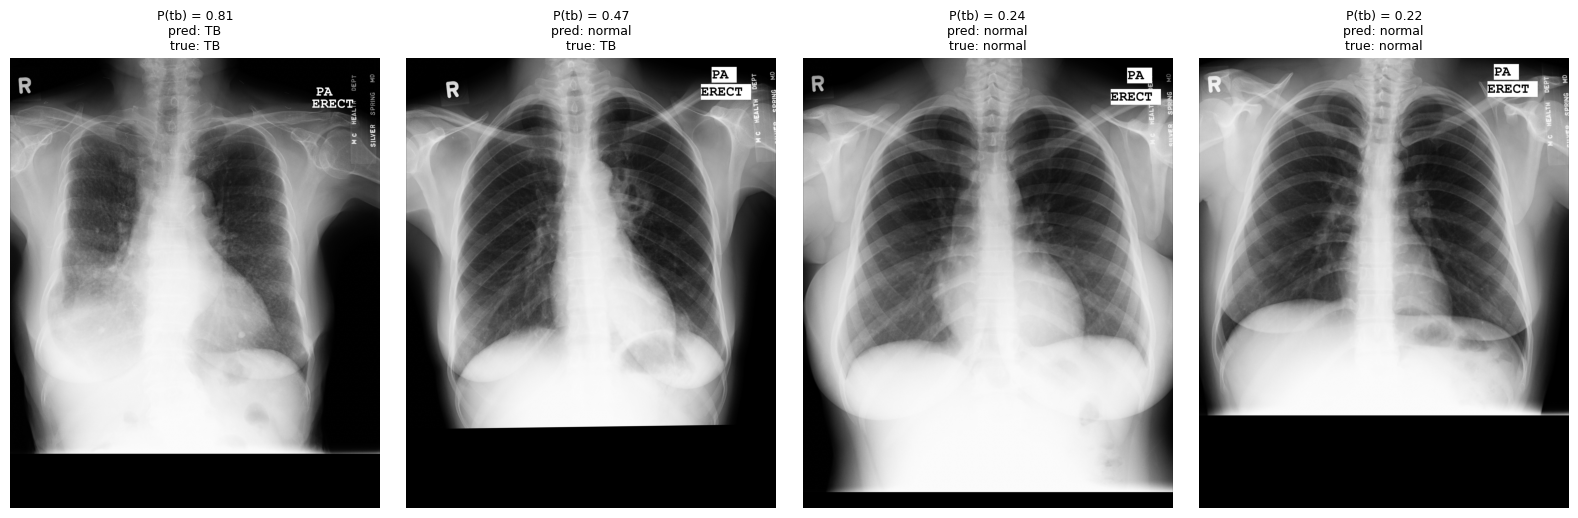

In [5]:
from viz_helpers import show_predictions

show_predictions(probe, probe_ds, MONTGOMERY_DIR)

### Segmentation probe

The same frozen encoder can be probed for **segmentation** instead of
classification. In segmentation mode (`output_keys={"img", "mask"}`) the encoder
returns dense `[B, D, H, W]` feature maps rather than one vector per image, and
`LinearProbeSegEvaluator` trains a small 1×1 conv head on top to predict a mask.

We segment the **lungs** on Montgomery, which ships left+right lung masks.
Everything else — frozen backbone, 5-fold CV, per-class metrics — mirrors the
classification probe above.

In [ ]:
from radharmony.evaluator import LinearProbeSegEvaluator

# Same MedSigLIP, now in segmentation mode: output_keys={"img", "mask"} makes the
# encoder emit dense [B, D, H, W] feature maps instead of one [B, D] vector.
seg_transform, seg_encoder, _text_encoder, _processor = make_medsiglip(
    device=DEVICE, output_keys={"img", "mask"}
)

# Montgomery ships left+right lung masks; output_mask=True fuses them into one
# binary lung mask per image, written to mask_output_dir.
seg_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    transform=seg_transform,
    output_mask=True,
    mask_output_dir="./cache/montgomery_lung_masks",
    cache_dir=None,
)

# Trains a 1x1 conv head over the frozen features per fold (background + lung).
seg_probe = LinearProbeSegEvaluator(
    image_encoder=seg_encoder,
    dataset=seg_ds,
    num_classes=2,
    n_folds=5,
    epochs=20,
    batch_size=8,
    device=DEVICE,
)
seg_results = seg_probe.evaluate()

# Average Dice / IoU across folds, per class.
seg_results.groupby("label")[["dice", "iou"]].mean()

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Fusing lung masks: 100%|██████████| 138/138 [00:00<00:00, 56453.13it/s]


training:   0%|          | 0/20 [00:00<?, ?epoch/s]

training:   0%|          | 0/20 [00:00<?, ?epoch/s]

training:   0%|          | 0/20 [00:00<?, ?epoch/s]

training:   0%|          | 0/20 [00:00<?, ?epoch/s]

training:   0%|          | 0/20 [00:00<?, ?epoch/s]

A per-class table of segmentation metrics (Dice, IoU, pixel accuracy,
sensitivity, specificity). `class_1` is the lung; `macro_average` aggregates the
foreground classes.

- **Dice** — overlap between predicted and true mask (1.0 perfect, 0.0 disjoint).

`ConvProbeSegEvaluator` (deeper head) and `UPerNetSegEvaluator` (full decoder)
drop in through the same interface — see
[`evaluator_tutorial.ipynb`](evaluator_tutorial.ipynb).

### Seeing the predicted masks

The table is an aggregate; the same head also produces masks you can look
at. `fit()` trains one deployment head (no k-fold), and
`predict(..., return_images=True)` runs it over the honest inner-val slice
`fit()` held out — returning the resized image, ground-truth mask, and
predicted mask per example, ready for overlays.

In [ ]:
from viz_helpers import show_masks

show_masks(seg_probe, seg_ds)

## Visual question answering (MedGemma protocol)

The probe used only the image encoder; the full **vision-language model** can
answer questions about an image. `VQAEvaluator` runs this, and
`make_medgemma_vqa` reproduces the MedGemma paper's setup (§3.4, Table 9):

- **Model** — MedGemma-4B instruction-tuned (`google/medgemma-4b-it`).
- **Prompt** — the exact VQA-RAD prompt from Appendix A7.
- **Decoding** — greedy (temperature 0).
- **No system persona** — the paper omits it for medical variants; we match
  (`system_message=None`).
- **Metrics** — token F1 over all questions + accuracy on the yes/no ("closed")
  subset.

The paper uses VQA-RAD and SLAKE; we use VQA-RAD (swap the dataset for SLAKE).

In [6]:
from radharmony.evaluator import VQAEvaluator
from radharmony.evaluator.backbones import make_medgemma_vqa
from radharmony.dataset import VQARadDataset

VQA_RAD_DIR = "/mnt/NAS4/datasets/external/VQA-RAD/VQA_RAD Image Folder"

# make_medgemma_vqa loads google/medgemma-4b-it and returns a transform (each
# image -> a PNG path the model reads) and an answerer (greedy decoding). It uses
# device_map="auto", so GPU pinning comes from the setup cell's
# CUDA_VISIBLE_DEVICES, not the `device` arg.
transform, answerer = make_medgemma_vqa(device=DEVICE)

vqa_ds = VQARadDataset(base_image_dir=VQA_RAD_DIR, transform=transform, cache_dir=None)

ev = VQAEvaluator(answerer, dataset=vqa_ds, output_dir="outputs/vqa")
df = ev.evaluate()
ev.save_results(df)  # writes results.csv + generations.csv to output_dir
df

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

answering VQA:   0%|          | 0/281 [00:00<?, ?batch/s]

Mean of empty slice
Degrees of freedom <= 0 for slice.


,fold,seed,bootstrap,label,token_f1,accuracy,token_recall
0,-1,-1,-1,overall,0.565488,NaN,NaN
1,-1,-1,-1,closed,0.753562,0.753562,NaN
2,-1,-1,-1,open,0.352811,NaN,0.34318


One row per bucket, matching MedGemma's Table 9. Each reports only the metrics
that make sense for it (hence the intentional NaNs). Answers are normalized
first — lowercased, punctuation and articles (a/an/the) stripped, split into
tokens — then scored on token overlap. The examples below use real VQA-RAD
questions and reference answers (illustrative model predictions).

**`overall` — mean token F1 across every question.** Token F1 is the multiset
overlap between prediction and reference: `P = overlap/|pred|`,
`R = overlap/|ref|`, `F1 = 2PR/(P+R)`.

> Q: *"where is the cavitary lesion?"* · ref `"Right upper lobe"` →
> `[right, upper, lobe]` · pred `"left upper lobe"` → `[left, upper, lobe]`.
> Overlap = 2, so P = R = 2/3, **F1 ≈ 0.67** — right structure, wrong side.

**`closed` — accuracy on yes/no questions** (reference is exactly "yes"/"no"),
plus their token F1. Accuracy grades the first yes/no token the model emits, so
a full sentence still counts.

> Q: *"Are the lungs normal appearing?"* · ref `"No"` · pred
> `"No, there are pulmonary nodules."` → first yes/no token is `no` →
> **correct (1.0)**. A pred of `"yes"` would score **0.0**.

**`open` — token F1 (as above) and token recall on the rest.** Recall is
`overlap/|ref|` — the fraction of reference tokens recovered, ignoring extra
words. The two together separate *completeness* from *conciseness*.

> Q: *"What abnormalities are seen within the lungs?"* · ref
> `"Pulmonary nodules"` → `[pulmonary, nodules]` · pred
> `"there are multiple pulmonary nodules"` →
> `[there, are, multiple, pulmonary, nodules]`. Overlap = 2, so **recall = 1.0**
> (both ref tokens found) but **F1 ≈ 0.57** (P = 2/5, docked for the extra words).

`ev.save_results(df)` also writes `generations.csv` with the actual answers.

- Swap `make_chexagent_vqa` to evaluate CheXagent-2 instead.
- These numbers cover the full VQA-RAD set; MedGemma's Table 9 uses a
  contamination-free split that isn't shipped, so values aren't bit-comparable.

### Seeing the answers

`generations.csv` holds every answer as text; here we pair a few images
with what the model said. We pull samples straight from the dataset (each
sample's `img` is the PNG path the transform wrote) and run the same
`answerer` on them.

In [ ]:
from viz_helpers import show_answers

show_answers(vqa_ds, answerer)

## Generating chest-X-ray reports (MedGemma protocol)

VQA asks a question; **report generation** asks the model to *write* the
findings. Same MedGemma-4B, different prompt. `make_medgemma_generator`
reproduces the paper's setup:

- **Task** — write the FINDINGS section for a MIMIC-CXR chest X-ray.
- **Indication-conditioned** — the exam's clinical indication is passed as
  context (fair: the reporting radiologist reads it too; it's input, not a
  scoring target).
- **Decoding** — greedy.
- **Metrics** — **RadGraph F1** (MedGemma's headline metric) plus **BLEU** for
  an n-gram-overlap point of comparison, both via RadEval. The demo scores
  findings; use `ref_section="impression"` for impression.

No training phase — the evaluator iterates the dataset once, generates, scores.

> **Environment.** RadGraph pins a different `transformers` from MedGemma. For a
> large run, generate here with `ev.generate_only("pairs.parquet")`, then score
> the parquet in a `radeval` venv (`uv pip install -e ".[radeval]"`). This demo
> scores inline. MIMIC-CXR is credentialed (PhysioNet).

> **First-run auth.** RadGraph downloads weights from `StanfordAIMI/RRG_scorers`
> on the first `ev.evaluate()`. If it 401s: (1) no HF token — run
> `.venv/bin/hf auth login` with a `read`-scoped token; (2) a pre-Xet token on
> the Xet-hosted repo — regenerate it, or set `HF_HUB_DISABLE_XET=1` before
> launching Jupyter. Cached after the first successful download.

In [ ]:
from radharmony.evaluator import ReportGenerationEvaluator
from radharmony.evaluator.backbones import make_medgemma_generator
from radharmony.dataset import MIMICCXRDataset

# MIMIC-CXR is credentialed (PhysioNet). Point these at your local copy.
MIMIC_IMAGE_DIR = "/mnt/NAS4/datasets/external/MIMIC-CXR-V2-AWS/files/"
MIMIC_REPORT_CSV = "/mnt/NAS4/datasets/external/MIMIC-CXR-V2-AWS/cxr-study-list.csv.gz"

# Same MedGemma-4B, now writing a findings narrative. Returns a transform (image
# -> PNG path) and a generator (greedy). Default prompt is the "<INDICATION>
# findings:" form; override with make_medgemma_generator(prompt="..."). Same
# device_map="auto" caveat as the VQA cell.
transform, generator = make_medgemma_generator(device=DEVICE)

# output_report=True makes each sample carry its reference report path.
gen_ds = MIMICCXRDataset(
    base_image_dir=MIMIC_IMAGE_DIR,
    report_csv_path=MIMIC_REPORT_CSV,
    transform=transform,
    output_report=True,
    cache_dir=None,
)

ev = ReportGenerationEvaluator(
    generator,
    dataset=gen_ds,
    ref_section="findings",  # swap to "impression" for that column
    use_indication=True,  # condition on the exam indication (input, not a target)
    metrics=[
        "bleu",
        "radgraph",
    ],  # BLEU (n-gram overlap) + RadGraph F1 (MedGemma's primary)
    max_samples=1000,  # small cap for the demo; remove for a full run
    output_dir="outputs/medgemma_report",
)
df = ev.evaluate()
ev.save_results(df)  # writes results.csv + generations.csv to output_dir
df

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generating reports:   0%|          | 0/47139 [00:00<?, ?batch/s]

Using device: cuda:0


Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead


Output()

,fold,seed,bootstrap,label,bleu,radgraph_simple,radgraph_partial,radgraph_complete
0,-1,-1,-1,report,0.0418,0.2622,0.2398,0.1778


One row (`label == "report"`). A `bleu` column, plus three RadGraph columns —
`radgraph_simple`, `radgraph_partial`, `radgraph_complete` (explained below).
The two metrics measure different things:

- **BLEU** — n-gram overlap with a brevity penalty. Surface-level and
  phrasing-sensitive: a clinically correct report worded differently from the
  reference scores low.
- **RadGraph F1** — extracts the clinical entities and relations from both
  reports and scores how well they match. Rewards the right *findings*, not the
  phrasing.

Reporting both shows the gap between lexical and clinical agreement.
`ev.save_results(df)` also writes `generations.csv` with reference and generated
findings side by side.

**How close to the paper?**

1. MedGemma reports RadGraph for findings *and* impression; the demo scores
   findings (`ref_section="impression"` for the other).
2. MedGemma's exact prompt isn't published — the recipe uses a faithful
   paraphrase (override with `prompt=`).
3. This runs over whatever MIMIC-CXR split you pass; the paper uses a specific
   test split.

Close replications, not bit-exact reproductions.

### Seeing the generated reports

The same idea for report generation: a few images beside their reference
findings and the model's generated findings. We take samples from the
dataset (each `report` is the path to the reference report) and run the
same `generator`.

In [ ]:
from viz_helpers import show_reports

show_reports(gen_ds, generator)

### How the RadGraph F1 columns are computed

RadEval returns three RadGraph F1 columns — `radgraph_simple`,
`radgraph_partial`, `radgraph_complete`: same metric, three severity levels.

**What RadGraph extracts.** A trained extractor (DyGIE++ with RadGraph-XL
weights) reads each report and returns a small graph:

- **Entities** — token spans labelled `ANAT-DP` (anatomy present), `OBS-DP`
  (observation present), `OBS-U` (uncertain), `OBS-DA` (absent).
- **Relations** — typed directed edges (`located_at`, `modify`,
  `suggestive_of`), always *source → target* (`small --modify--> pneumothorax`).

The same extractor runs on both reports, so its errors partially cancel.

**Reference** — *"Small pneumothorax in the right lung apex"* → `pneumothorax`
(OBS-DP) `located_at` `apex`; `small` (OBS-DP) `modify` `pneumothorax`; `right`
(ANAT-DP) `modify` `apex`; `apex` (ANAT-DP), no outgoing edge. (See the diagram
below.)

**Scoring.** Each report becomes a set of tuples, then `P = matched / |hyp|`,
`R = matched / |ref|`, `F1 = 2PR/(P+R)`. The columns differ only in the tuple
shape each entity contributes:

| Column | Tuple form | Semantics |
|---|---|---|
| `radgraph_simple`   | `(tokens, label)` | Entity only; relations ignored. |
| `radgraph_partial`  | `(tokens, label)`, or `(tokens, label, True)` if it has an outgoing edge | Entity + whether it links to *something*. |
| `radgraph_complete` | `(tokens, label)`, or one `(tokens, label, rel, target)` **per outgoing edge** | The full edge. |

**Example 1 — "...in the LEFT apex" (wrong side).** Only `right`→`left` changes.
At every level 3 of 4 tuples match and the single token error is charged exactly
once: **simple = partial = complete = 0.75**.

**Example 2 — "Pneumothorax is present" (ungrounded).** The extractor returns
one entity, `pneumothorax` (OBS-DP), no relations.

- *simple*: `hyp = {(pneumothorax, OBS-DP)}`, 1 of 4 ref tuples matches →
  P = 1.00, R = 0.25, **F1 ≈ 0.40**.
- *partial / complete*: the reference's `pneumothorax` is a 3-/4-tuple (it has an
  outgoing edge), the hypothesis's is a bare 2-tuple → no match → **F1 = 0.00**.

| Hypothesis | simple | partial | complete |
|---|---:|---:|---:|
| "...in the **left** apex" | 0.75 | 0.75 | 0.75 |
| "Pneumothorax is present" | 0.40 | **0.00** | 0.00 |

Two takeaways:

- **`simple ≥ partial ≥ complete`** always holds — a match on a stricter tuple
  implies a match on the looser one.
- **`partial` is where grounding gets scored.** Naming findings in isolation
  (Example 2) earns `simple` credit but zero `partial` credit — the behavior
  most RRG papers want punished.

**Which to quote against MedGemma.** MedGemma cites "RadGraph F1" without a
level; the convention is **`radgraph_partial`** (Yu et al. 2023's `F1RadGraph`
default). RadEval hardcodes `model_type="radgraph-xl"`; older BERT-based
`radgraph` numbers aren't directly comparable.

![RadGraph F1 worked examples: the reference graph and the two hypothesis graphs, side by side](figs/RadGraph.png)

*Reference vs. the two hypotheses from the examples above. Both `modify` arrows
point modifier → head; red marks what differs from the reference.*

## Summary

Three ways to evaluate a foundation model in RadHarmony:

- **Linear probe** — `LinearProbeEvaluator` on frozen image embeddings.
- **VQA** — `VQAEvaluator` on generated answers (token F1 + closed accuracy).
- **Report generation** — `ReportGenerationEvaluator` on generated findings
  (RadGraph F1).

The VQA and report-gen sections follow the MedGemma paper's protocol. Swap in
another recipe (`make_chexagent_vqa`, `make_chexagent_generator`,
`make_maira2_generator`) to run a different model through the same harness.

### Further reading

| Notebook | What it adds |
|---|---|
| [`radharmony_hands_on.ipynb`](radharmony_hands_on.ipynb) | The dataset-loading intro this builds on |
| [`evaluator_tutorial.ipynb`](evaluator_tutorial.ipynb) | The full evaluator API — k-NN, SVM, prototype, zero-shot, fine-tune, segmentation |
| [`../evaluator/report_generation_example.ipynb`](../evaluator/report_generation_example.ipynb) | The two-stage report-gen flow (generate, then score with the full RadEval suite) |

Full docs: **[f10409.github.io/RadHarmony](https://f10409.github.io/RadHarmony)**